In [387]:
import pickle
import numpy as np
import pandas as pd
import os
import re

import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable

from nsga_population import *
from typing import List
from individual import Individual, PermutationChromosome

import matplotlib.pyplot as plt
import matplotlib.patches as patches

log_base = "..\\logdata_2\\"
experiment_folders = ["Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-20_22_19_28_hash_base", "Experiment_2_2025-02-24_09_40_06_classical", "Experiment_2_2025-02-24_09_40_06_improved_random_key"] #["Experiment_1_2024-09-27_classical_1", "Experiment_1_2024-09-30_12_05_58_215187", "Experiment_1_2024-09-30_13_51_09_109136", "Experiment_1_2024-09-30_15_31_13_949606"]
subfolder_names = ["pareto_front_abz8_quantum_position_encoding_restricted_0", "pareto_front_abz8_quantum_hash_base_encoding_2", "pareto_front_abz8_classical_8", "pareto_front_abz8_qmea_enhanced_random_key_8"] #"pareto_front_ft20_quantum_hash_base_encoding_0\\pareto_front.pkl"

In [388]:
def import_pareto_front(log_base, experiment_folders, subfolder_name):
    file_path = os.path.join(os.path.join(log_base, experiment_folders), subfolder_name)

    with open(file_path, "rb") as read_pop_dump:
        cur_pop = pickle.load(read_pop_dump)

    X = []
    Y = []
    for individual in cur_pop:
        x, y = individual.cur_fitness
        add_individual = True
        for i in range(len(X)):
            if x == X[i] and y == Y[i]:
                add_individual = False
        if add_individual:
            X.append(x)
            Y.append(y)

    front_array = np.array([X, Y])
    working_index = np.argmin(front_array[0])
    result_list = np.empty_like(front_array)
    front_array = front_array.tolist()

    for i in range(len(X)):
        result_list[0, i] = front_array[0].pop(working_index)
        result_list[1, i] = front_array[1].pop(working_index)
        # Calculate distance to other points to find next index
        min_distance = None
        for j in range(len(front_array[0])):
            cur_distance = np.sqrt(np.sum((result_list[:, i] - np.array([front_array[0][j], front_array[1][j]]))**2))
            if not min_distance or min_distance > cur_distance:
                working_index = j
                min_distance = cur_distance
            
    return result_list

    

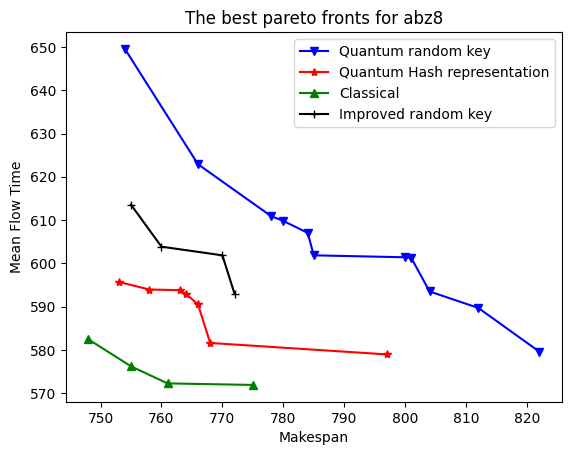

In [597]:
experiment_folders = ["Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-19_23_23_50_random_key_main","Experiment_2_2025-02-19_23_23_50_random_key_main"]
subfolder_names = ["pareto_front_abz9_quantum_position_encoding_restricted_3", "pareto_front_abz9_quantum_position_encoding_restricted_2",  "pareto_front_abz9_quantum_position_encoding_restricted_8", "pareto_front_abz9_quantum_position_encoding_restricted_1"]

style_list = [("v", "b"), ("*", "r"), ("^", "green"), ("+", "black")]
algorithms = ["Quantum random key", "Quantum Hash representation", "Classical", "Improved random key"]
for i, experiment in enumerate(experiment_folders):
    cur_path = os.path.join(subfolder_names[i], "pareto_front.pkl")
    result_list = import_pareto_front(log_base, experiment, cur_path)
    plt.plot(result_list[0, :], result_list[1, :], marker=style_list[i][0], c=style_list[i][1], label=algorithms[i])

plt.title("The best pareto fronts for abz8")
plt.xlabel("Makespan")
plt.ylabel("Mean Flow Time")
plt.legend()
plt.show()

In [9]:
experiment_folders

['Experiment_2_2025-02-19_23_23_50_random_key_main',
 'Experiment_2_2025-02-20_22_19_28_hash_base',
 'Experiment_2_2025-02-24_09_40_06_classical',
 'Experiment_2_2025-02-24_09_40_06_improved_random_key']

In [10]:
result_list

array([[714.  , 722.  , 723.  , 727.  , 734.  , 737.  , 739.  , 741.  ,
        742.  , 753.  ],
       [626.85, 618.  , 617.05, 614.55, 613.75, 611.75, 610.1 , 609.9 ,
        602.7 , 591.65]])

In [74]:
start_index = ord("A")
last_index = ord("Z")
alphabet_size = 26

In [ ]:
def get_letter_code(index: int, alphabet_size: int, start_index: int) -> str:
    """This funciton is used to create the letter code for the job identifiers

    Parameters
    ----------
    index : int
        The corresponding integer value of the job identifier
    alphabet_size : int
        THe number of different letters in the alphabet
    start_index : int
        The offsett index for the char. For capital letters, this value should be 65 because ord('A') -> 65

    Returns
    -------
    str
        The letter code for the provided job number
    """
    res_list = []
    counter = 0
    while True:
        cur_position = alphabet_size**counter
        rest = index % alphabet_size**(counter+1)
        contribution = rest // cur_position
        if counter > 0:
            contribution -= 1
        res_list.append(contribution)
        if index // alphabet_size**(counter+1) == 0:
            break
        counter += 1

    res_list.reverse()
    letter_indexes = np.array(res_list) + start_index
    res_str = ""
    for letter in letter_indexes:
        res_str += chr(letter)
    
    return res_str

def get_operation_code_list(current_individual) -> list:
    str_operation_list = []
    job_counters = np.ones(shape=current_individual.n_jobs)
    for operation in current_individual.schedule.operation_list:
        # For each operation in the schedule -> find the operation code
        cur_job_number = operation.job
        # Get the number of times the job already has been processed
        cur_count = job_counters[cur_job_number]
        # Increment the job count for later iterations
        job_counters[cur_job_number] += 1
        letter_code = get_letter_code(cur_job_number, alphabet_size, start_index)
        str_operation_list.append(f"{letter_code}{int(cur_count)}")
    
    return str_operation_list

def plot_schedule_as_gnatt(individual, box_height: float=0.4, plot_labels: bool=False, selected_cm: str="plt.cm.cividis", figsize=(10,5), problem_name: str="Unknown"):
    
    fig, ax = plt.subplots(figsize=figsize)

    machine_stop_times = np.zeros(shape=individual.n_machines)
    job_stop_times = np.zeros(shape=individual.n_jobs)
    
    str_operation_list = get_operation_code_list(individual)
    
    for o, cur_operation in enumerate(individual.schedule.operation_list):
        cur_machine = cur_operation.machine
        cur_job_number = cur_operation.job 
        # Create the collor for this job
        cur_color = list(eval(selected_cm)(cur_job_number/(individual.n_jobs-1)))
        cur_color[-1] = 0.6
        cur_color = tuple(cur_color)
        # Get the next start time
        cur_start_time = np.max([machine_stop_times[cur_machine], job_stop_times[cur_job_number]])
        # Create the rectangle for the operation
        rect = patches.Rectangle((cur_start_time, cur_machine - box_height + 1), cur_operation.duration, 2*box_height, linewidth=1, edgecolor="None", facecolor=cur_color, fill=True)
        # Add the operation label in the middle
        if plot_labels:
            ax.annotate(str_operation_list[o], (cur_start_time + cur_operation.duration/2, cur_machine+1), fontsize=10, ha='center', va='center', color="black")
        # update machine and job stop times
        machine_stop_times[cur_machine] = cur_start_time + cur_operation.duration
        job_stop_times[cur_job_number] = cur_start_time + cur_operation.duration
        ax.add_patch(rect)


    ax.set_ylim(0, individual.n_machines + 1)
    ax.set_xlim(0, individual.cur_fitness[0] + 40)
    ax.set_yticks(np.arange(1, individual.n_machines + 1))
    ax.vlines(individual.cur_fitness[0], 1, individual.n_machines, colors="r", lw=2.5)
    ax.text(individual.cur_fitness[0]-40, individual.n_machines + 0.5, f"Makespan: {int(individual.cur_fitness[0])}")
    plt.title(f"Gnatt chart of schedule for the {'unknown'} problem instance")
    plt.xlabel("Time")
    plt.ylabel("Machine ID")
    plt.show()

In [408]:
subfolder_name = "pareto_front_ta70_qmea_enhanced_random_key_0" #subfolder_names[0]
experiment_folder = "Experiment_2_2025-02-25_16_49_10_240059" #experiment_folders[0]
file_path = os.path.join(os.path.join(log_base, experiment_folder), os.path.join(subfolder_name, "pareto_front.pkl"))

with open(file_path, "rb") as read_pop_dump:
    cur_pop = pickle.load(read_pop_dump)

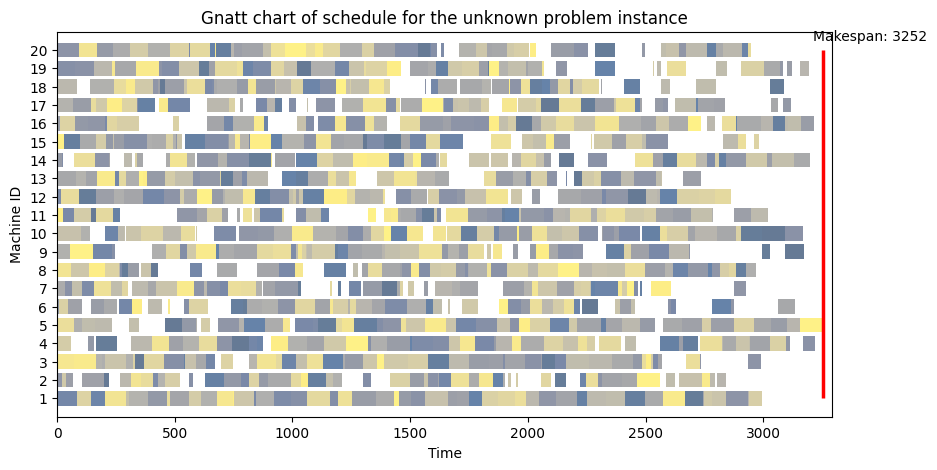

In [409]:
plot_schedule_as_gnatt(cur_pop[6])

In [410]:
str(get_operation_code_list(cur_pop[6])).replace("[", "").replace("]", "").replace("'", "").replace(" ", "")

'V1,W1,P1,O1,N1,R1,M1,I1,AW1,X1,J1,AX1,AR1,AJ1,H1,AM1,Z1,AK1,AU1,G1,AN1,AT1,L1,R2,AA1,K1,AA2,AC1,AV1,O2,L2,AX2,AK2,AQ1,AG1,C1,Y1,AF1,S1,W2,AT2,Q1,AN2,U1,AR2,AI1,N2,Z2,I2,F1,O3,AQ2,AW2,M2,AE1,A1,G2,B1,AJ2,AC2,T1,AK3,AA3,AV2,P2,S2,AP1,Q2,Y2,Z3,AS1,H2,AN3,AH1,O4,AT3,AW3,A2,U2,AD1,AU2,R3,X2,AG2,P3,K2,AQ3,B2,W3,AO1,V2,F2,G3,Y3,AC3,D1,I3,AN4,AE2,AP2,AD2,Q3,U3,AE3,AC4,AO2,AV3,AO3,B3,AF2,Z4,Y4,AK4,G4,AD3,AM2,AT4,AJ3,AM3,L3,AV4,AL1,Q4,AF3,AH2,AW4,AX3,V3,K3,G5,A3,AQ4,AW5,AA4,AD4,Z5,O5,AH3,AC5,Y5,P4,N3,D2,D3,AO4,V4,I4,A4,X3,S3,M3,A5,AD5,Y6,AN5,M4,K4,AA5,AM4,R4,J2,AQ5,AV5,AT5,AV6,X4,AN6,AO5,U4,AK5,Z6,N4,AH4,AM5,AK6,AL2,A6,J3,AC6,AH5,AF4,S4,AT6,AV7,D4,X5,AI2,AH6,AJ4,K5,AR3,AK7,H3,G6,AP3,K6,N5,AQ6,AG3,Z7,O6,Z8,M5,AV8,AQ7,AJ5,AX4,AA6,L4,Z9,G7,D5,B4,V5,AC7,U5,H4,N6,AN7,O7,AK8,E1,P5,I5,G8,S5,AU3,E2,AQ8,W4,AU4,C2,X6,K7,AN8,AP4,AM6,F3,J4,U6,D6,Z10,Y7,AA7,AE4,H5,S6,AC8,P6,M6,N7,AN9,B5,G9,AB1,AW6,U7,AC9,AM7,I6,O8,C3,W5,W6,AU5,AR4,A7,S7,R5,AS2,W7,Z11,AA8,P7,AU6,B6,I7,AI3,H6,AB2,K8,T2,H7,AS3,F4,AQ9,B7,H8,AT7

In [411]:
get_letter_code(26, 26, 65)

'AA'

Calculating the hypervolume

In [430]:
test_points = np.array([[1,3],[2,2],[3,1]])
reference_point = np.array([[5,5]])
n_points = test_points.shape[0]

In [502]:
def calc_hypervolume(front_points: np.ndarray, reference_point: np.ndarray):
    total_volume = 0
    n_points = front_points.shape[0]
    for point in range(n_points):
        if point < n_points-1:
            cur_width = np.abs(front_points[point+1][0] - front_points[point][0])
        else:
            cur_width = np.abs(reference_point[0] - front_points[point][0])

        cur_height = np.abs(reference_point[1] - front_points[point][1])

        total_volume += cur_height * cur_width

    return total_volume

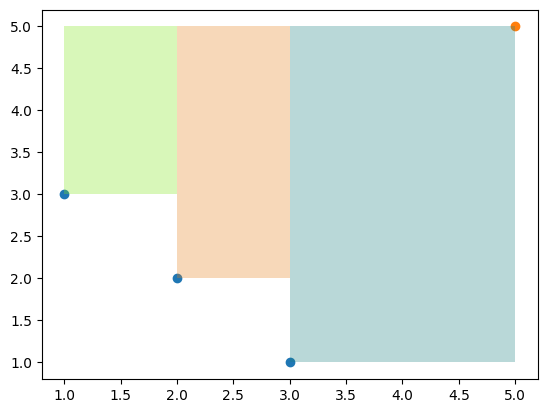

In [450]:
fig, ax = plt.subplots()
plt.scatter(test_points[:, 0], test_points[:, 1])
plt.scatter(reference_point[0][0], reference_point[0][1])

rect_1 = patches.Rectangle((1, 3), 1, 2, linewidth=1, edgecolor="None", facecolor=(0.5, 0.9, 0.1, 0.3), fill=True)
ax.add_patch(rect_1)

rect_1 = patches.Rectangle((2, 2), 1, 3, linewidth=1, edgecolor="None", facecolor=(0.9, 0.5, 0.1, 0.3), fill=True)
ax.add_patch(rect_1)

rect_1 = patches.Rectangle((3, 1), 2, 4, linewidth=1, edgecolor="None", facecolor=(0.1, 0.5, 0.5, 0.3), fill=True)
ax.add_patch(rect_1)

In [556]:
n_repetitions = 10
experiment_folders = ["Experiment_2_2025-02-19_23_23_50_random_key_main", "Experiment_2_2025-02-20_22_19_28_hash_base", "Experiment_2_2025-02-24_09_40_06_classical", "Experiment_2_2025-02-24_09_40_06_improved_random_key"]
method_names = ["quantum_position_encoding_restricted", "quantum_hash_base_encoding", "classical", "qmea_enhanced_random_key"]
problem_names = ["ft06", "ft10", "ft20", "abz7", "abz8", "abz9", "la28", "la40", ]
front_dataset = {"Problem" : [], "Method" : [], "Repetition" : [], "Makespan" : [], "Mean Flow Time" : []}
for problem_name in problem_names:
    for i, method_name in enumerate(method_names):
        for repetition in range(n_repetitions):
            # Create the path to the front file
            file_path = os.path.join(os.path.join(log_base, experiment_folders[i]), os.path.join(f"pareto_front_{problem_name}_{method_name}_{repetition}", "pareto_front.pkl"))
            # Import the population object
            with open(file_path, "rb") as read_pop_dump:
                cur_front = pickle.load(read_pop_dump)

            for indiv in cur_front:
                front_dataset["Problem"].append(problem_name)
                front_dataset["Method"].append(method_name)
                front_dataset["Repetition"].append(repetition)
                front_dataset["Makespan"].append(indiv.cur_fitness[0])
                front_dataset["Mean Flow Time"].append(indiv.cur_fitness[1])

            
front_dataset = pd.DataFrame(front_dataset)
front_dataset.drop_duplicates(inplace=True)
min_columns = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.min()).rename(columns={"Makespan" : "min makespan", "Mean Flow Time" : "min mean flow time"})
max_columns = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.max()).rename(columns={"Makespan" : "max makespan", "Mean Flow Time" : "max mean flow time"})
front_dataset = pd.concat([front_dataset, min_columns, max_columns], axis=1)
front_dataset

,Problem,Method,Repetition,Makespan,Mean Flow Time,min makespan,min mean flow time,max makespan,max mean flow time
0,ft06,quantum_position_encoding_restricted,0,58.0,39.666667,57.0,39.666667,58.0,42.5
1,ft06,quantum_position_encoding_restricted,0,57.0,42.500000,57.0,39.666667,58.0,42.5
11,ft06,quantum_position_encoding_restricted,1,58.0,39.666667,57.0,39.666667,58.0,42.5
12,ft06,quantum_position_encoding_restricted,1,57.0,42.500000,57.0,39.666667,58.0,42.5
19,ft06,quantum_position_encoding_restricted,2,58.0,39.666667,57.0,39.666667,58.0,42.5
...,...,...,...,...,...,...,...,...,...
6170,la40,qmea_enhanced_random_key,9,1291.0,1100.533333,1278.0,1071.866667,1528.0,1181.8
6171,la40,qmea_enhanced_random_key,9,1354.0,1091.333333,1278.0,1071.866667,1528.0,1181.8
6172,la40,qmea_enhanced_random_key,9,1332.0,1099.466667,1278.0,1071.866667,1528.0,1181.8
6173,la40,qmea_enhanced_random_key,9,1341.0,1095.066667,1278.0,1071.866667,1528.0,1181.8


Normalization of makespan and mean flow time with min/max scaling

In [579]:
def min_max_scaling(x):
    cur_makespan = (x["Makespan"] - x["min makespan"])/(x["max makespan"] - x["min makespan"])
    cur_mean_flow_time = (x["Mean Flow Time"] - x["min mean flow time"])/(x["max mean flow time"] - x["min mean flow time"])
    new_columns = pd.concat([x, cur_makespan, cur_mean_flow_time], axis=1).reset_index(drop=True)
    return new_columns

norm_df = front_dataset.groupby(["Problem"]).apply(min_max_scaling, include_groups=False).reset_index().rename(columns={0 : "Makespan norm", 1 : "Mean Flow Time norm"})
norm_df

,Problem,level_1,Method,Repetition,Makespan,Mean Flow Time,min makespan,min mean flow time,max makespan,max mean flow time,Makespan norm,Mean Flow Time norm
0,abz7,0,quantum_position_encoding_restricted,0,711.0,609.000000,699.0,583.900000,805.0,640.45,0.113208,0.443855
1,abz7,1,quantum_position_encoding_restricted,0,801.0,593.650000,699.0,583.900000,805.0,640.45,0.962264,0.172414
2,abz7,2,quantum_position_encoding_restricted,0,724.0,600.150000,699.0,583.900000,805.0,640.45,0.235849,0.287356
3,abz7,3,quantum_position_encoding_restricted,0,751.0,594.900000,699.0,583.900000,805.0,640.45,0.490566,0.194518
4,abz7,4,quantum_position_encoding_restricted,1,702.0,618.850000,699.0,583.900000,805.0,640.45,0.028302,0.618037
...,...,...,...,...,...,...,...,...,...,...,...,...
1541,la40,166,qmea_enhanced_random_key,9,1291.0,1100.533333,1278.0,1071.866667,1528.0,1181.80,0.052000,0.260764
1542,la40,167,qmea_enhanced_random_key,9,1354.0,1091.333333,1278.0,1071.866667,1528.0,1181.80,0.304000,0.177077
1543,la40,168,qmea_enhanced_random_key,9,1332.0,1099.466667,1278.0,1071.866667,1528.0,1181.80,0.216000,0.251061
1544,la40,169,qmea_enhanced_random_key,9,1341.0,1095.066667,1278.0,1071.866667,1528.0,1181.80,0.252000,0.211037


In [583]:
w_reference_point = front_dataset.groupby(["Problem"])[["Makespan", "Mean Flow Time"]].transform(lambda x: x.max()).rename(columns={"Makespan" : "Reference_1", "Mean Flow Time" : "Reference_2"})
w_reference_point_norm = norm_df.groupby(["Problem"])[["Makespan norm", "Mean Flow Time norm"]].transform(lambda x: x.max()).rename(columns={"Makespan norm" : "Reference_1", "Mean Flow Time norm" : "Reference_2"})

In [584]:
hypervol_ready = pd.concat([front_dataset, w_reference_point], axis=1)
hypervol_ready_norm = pd.concat([norm_df, w_reference_point_norm], axis=1)

In [586]:
hypervolume_res = hypervol_ready.groupby(["Problem", "Method", "Repetition"]).apply(lambda x: calc_hypervolume(x[["Makespan", "Mean Flow Time"]].to_numpy(), x[["Reference_1", "Reference_2"]].to_numpy()[0,:]), include_groups=False) 
hypervolume_res = hypervolume_res.groupby(["Problem", "Method"]).agg(["mean", "min", "max", "std"]).reset_index()
hypervolume_res_norm = hypervol_ready_norm.groupby(["Problem", "Method", "Repetition"]).apply(lambda x: calc_hypervolume(x[["Makespan norm", "Mean Flow Time norm"]].to_numpy(), x[["Reference_1", "Reference_2"]].to_numpy()[0,:]), include_groups=False) 
hypervolume_res_norm = hypervolume_res_norm.groupby(["Problem", "Method"]).agg(["mean", "min", "max", "std"]).reset_index()

In [588]:
hypervolume_res_norm.columns

Index(['Problem', 'Method', 'mean', 'min', 'max', 'std'], dtype='object')

<Axes: title={'center': 'Mean Hypervolume for different benchmarks'}, xlabel='Problem', ylabel='max'>

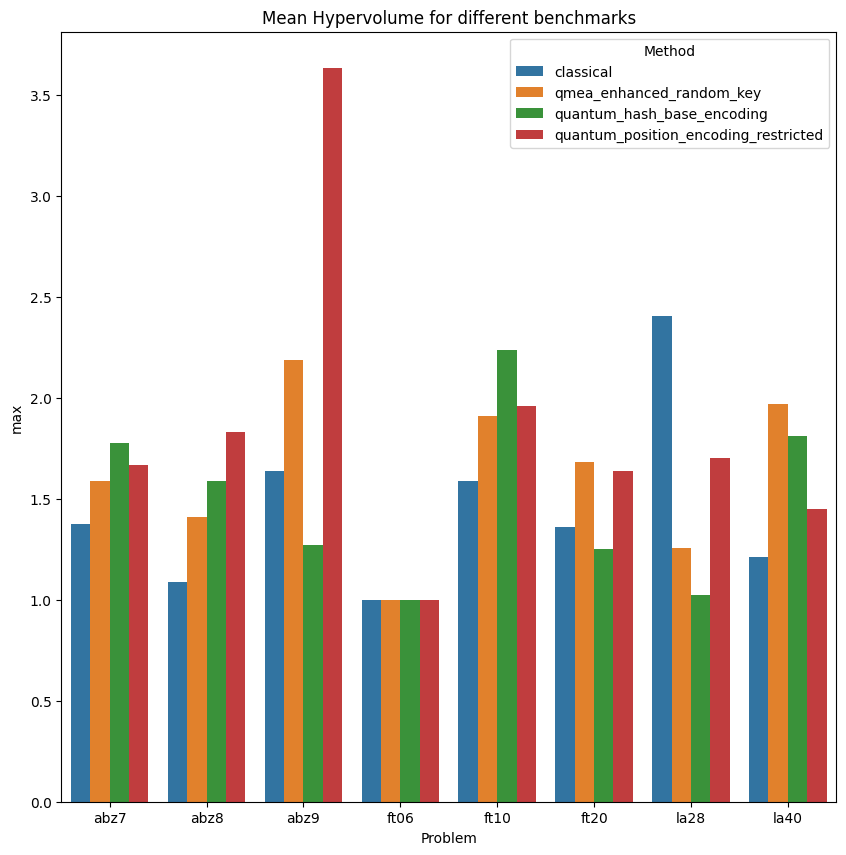

In [591]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Mean Hypervolume for different benchmarks")
sns.barplot(data=hypervolume_res_norm, x="Problem", y="max", hue="Method", ax=ax)

In [544]:
test = np.arange(10)

In [547]:
(test - test.min())/(test.max() - test.min())

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])